In [1]:
# Common Libraries
import pandas as pd
import numpy as np
import datetime
from pathlib import Path

import scipy.stats as stats

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [36]:
# Additional Libraries
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

from scipy.stats import boxcox, boxcox_normmax
from scipy.special import inv_boxcox
from sklearn.preprocessing import PowerTransformer

In [3]:
# Set working directory to root of git repository
import os
import subprocess
repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
os.chdir(repo_root)

---
### Prepare data

In [4]:
# Import data
utmb_results_years = [2022, 2023, 2024, 2025]

data_path = Path("data")
utmb_race_results_runner_statistics_path = data_path / "utmb_race_results_runner_statistics"

# Year by year Combined Race Results and Runner Statistics data
race_results_runner_statistics_data_dict = {
    year: pd.read_csv(utmb_race_results_runner_statistics_path / f"utmb_{year}_race_results_runner_statistics.csv")
    for year in utmb_results_years
}

# All years Combined Race Results and Runner Statistics data
race_results_runner_statistics_data = pd.read_csv(utmb_race_results_runner_statistics_path / f"utmb_race_results_runner_statistics.csv", low_memory=False)

In [5]:
# Clean data

# Runner final status:
# - hd --> Out of time on some of the checkpoints [Finisher = False]
# - a --> Abandoned (withdrew voluntarily) [Finisher = False]
# - s --> Did not finish? [Finisher = False]
# - f --> Finisher [Finisher = True]
display(race_results_runner_statistics_data[["runner_final_status", "runner_is_finisher"]].value_counts(normalize=True).reset_index())
race_results_runner_statistics_finished_data = race_results_runner_statistics_data.query("runner_is_finisher == @True").reset_index(drop=True).copy()

,runner_final_status,runner_is_finisher,proportion
0,f,True,0.659945
1,a,False,0.301335
2,hd,False,0.038625
3,s,False,0.000095


In [6]:
# About
for year in race_results_runner_statistics_data["race_year"].unique():
    data_tmp = race_results_runner_statistics_data.query("race_year == @year").reset_index(drop=True).copy()
    data_finisher_tmp = race_results_runner_statistics_finished_data.query("race_year == @year").reset_index(drop=True).copy()
    print(f"\nYear: {year}")
    print("---------------------------------------")
    print("Number of starters = {:,}".format(len(data_tmp)))
    print("Proportion of finishers = {:.1%}".format(data_tmp["runner_is_finisher"].mean()))
    print("Finish time: mean = {:.2f}h, std = {:.2f}h, q25 = {:.2f}h, q75 = {:.2f}h".format(
        data_finisher_tmp["runner_race_time_hours"].mean(),
        data_finisher_tmp["runner_race_time_hours"].std(),
        data_finisher_tmp["runner_race_time_hours"].quantile(0.25),
        data_finisher_tmp["runner_race_time_hours"].quantile(0.75),
    ))
    print("Fastest finish time = {:.2f}h, Slowest finish time = {:.2f}h".format(
        data_finisher_tmp["runner_race_time_hours"].min(),
        data_finisher_tmp["runner_race_time_hours"].max(),
    ))



Year: 2022
---------------------------------------
Number of starters = 2,627
Proportion of finishers = 68.1%
Finish time: mean = 39.03h, std = 5.77h, q25 = 35.38h, q75 = 43.97h
Fastest finish time = 19.82h, Slowest finish time = 47.20h

Year: 2023
---------------------------------------
Number of starters = 2,687
Proportion of finishers = 65.4%
Finish time: mean = 39.04h, std = 5.88h, q25 = 35.38h, q75 = 43.89h
Fastest finish time = 19.63h, Slowest finish time = 48.27h

Year: 2024
---------------------------------------
Number of starters = 2,760
Proportion of finishers = 63.8%
Finish time: mean = 39.03h, std = 6.00h, q25 = 35.37h, q75 = 44.01h
Fastest finish time = 19.91h, Slowest finish time = 46.76h

Year: 2025
---------------------------------------
Number of starters = 2,489
Proportion of finishers = 66.9%
Finish time: mean = 39.37h, std = 6.18h, q25 = 35.65h, q75 = 44.61h
Fastest finish time = 19.32h, Slowest finish time = 47.08h


In [7]:
# Train & Test data split ~> Train data = {2022, 2023, 2024}, Test data = {2025}

race_results_runner_statistics_train = race_results_runner_statistics_data.query("race_year != 2025").reset_index(drop=True).copy()
race_results_runner_statistics_finished_train =  race_results_runner_statistics_finished_data.query("race_year != 2025").reset_index(drop=True).copy()

race_results_runner_statistics_test = race_results_runner_statistics_data.query("race_year == 2025").reset_index(drop=True).copy()
race_results_runner_statistics_test = race_results_runner_statistics_finished_data.query("race_year == 2025").reset_index(drop=True).copy()

---
### Analysis

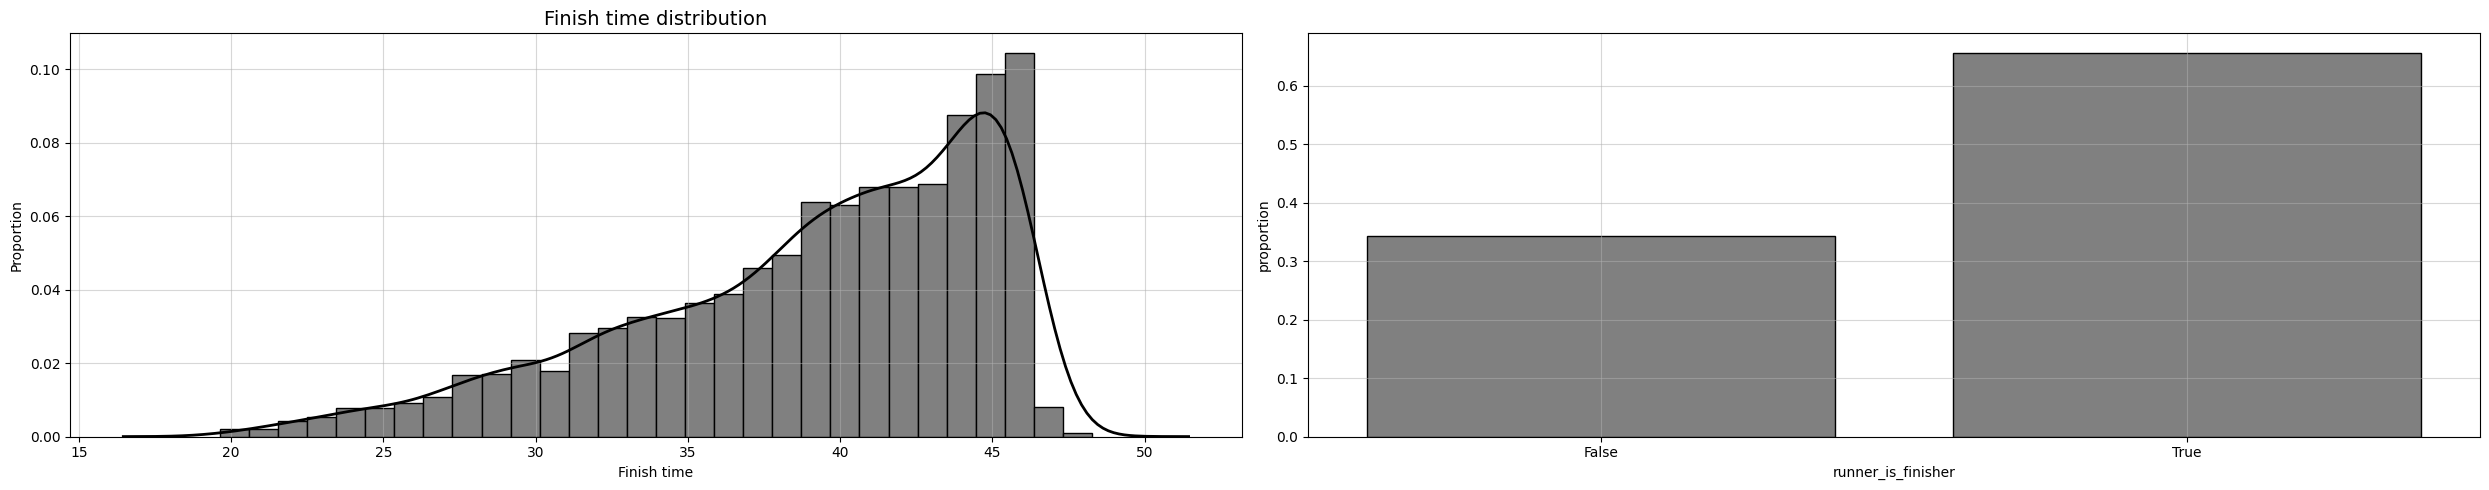

In [8]:
# Finish time distribution & DNF proportion distribution
fix, ax = plt.subplots(1,2, figsize=(25,5))

ax[0].set_title("Succesfull Finish distribution", fontsize=14)
prop_df = race_results_runner_statistics_train["runner_is_finisher"].value_counts(normalize=True) .reset_index()
sns.barplot(x="runner_is_finisher", y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[1])
ax[0].set_xlabel("Finisher")
ax[0].set_ylabel("Proportion")


ax[0].set_title("Finish time distribution", fontsize=14)
ax[0].hist(race_results_runner_statistics_finished_train["runner_race_time_hours"], bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(race_results_runner_statistics_finished_train["runner_race_time_hours"], ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Finish time")

for i in [0,1]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

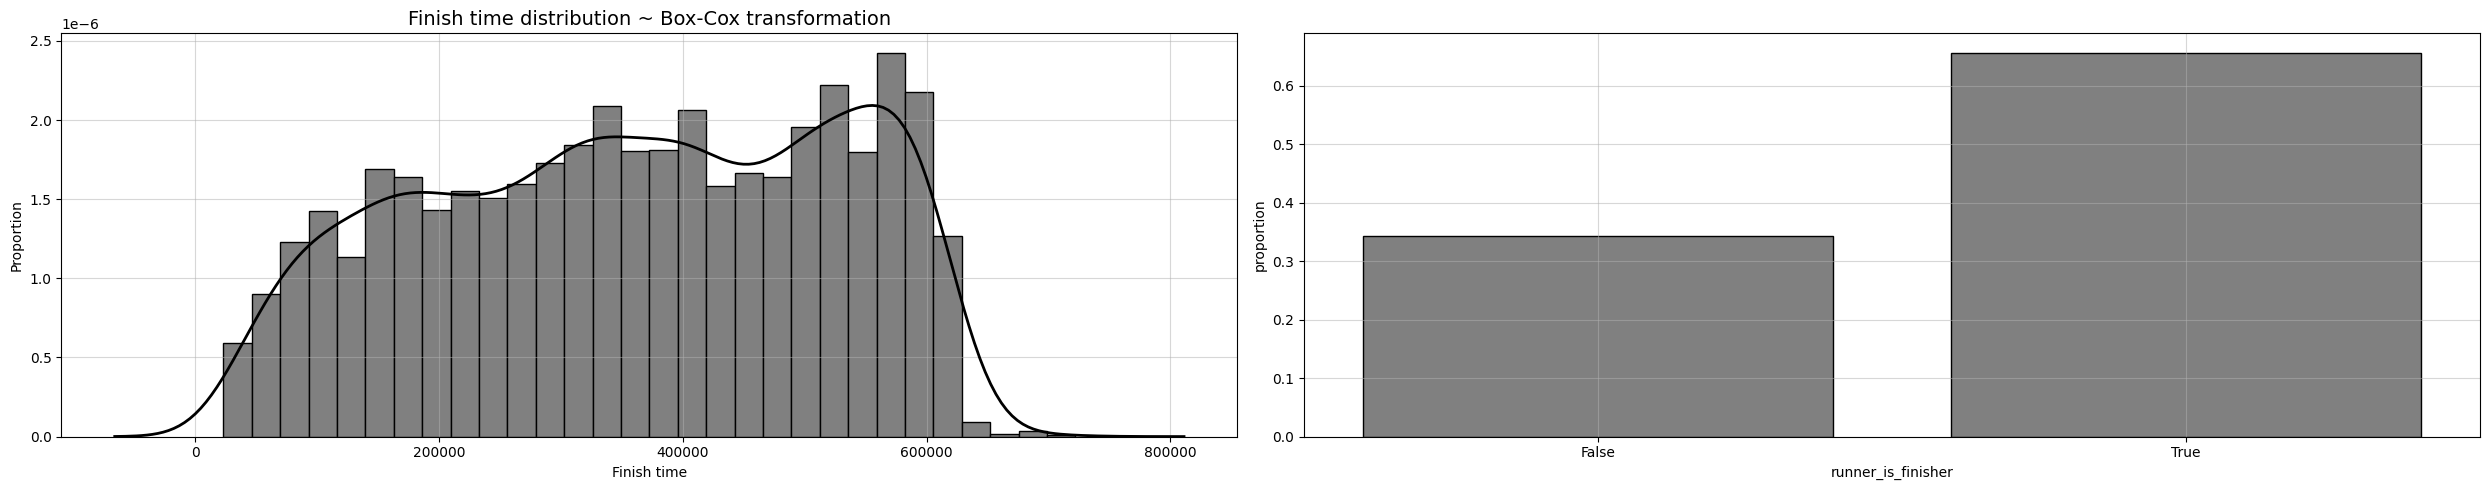

In [9]:
# Box-Cox Finish time distribution & DNF proportion distribution

target = race_results_runner_statistics_finished_train["runner_race_time_hours"]
lambda_bc = boxcox_normmax(target)
target_bc = boxcox(target, lmbda=lambda_bc)

fix, ax = plt.subplots(1,2, figsize=(25,5))

ax[0].set_title("Succesfull Finish distribution", fontsize=14)
prop_df = race_results_runner_statistics_train["runner_is_finisher"].value_counts(normalize=True) .reset_index()
sns.barplot(x="runner_is_finisher", y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[1])
ax[0].set_xlabel("Finisher")
ax[0].set_ylabel("Proportion")


ax[0].set_title("Finish time distribution ~ Box-Cox transformation", fontsize=14)
ax[0].hist(target_bc, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(target_bc, ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Finish time")

for i in [0,1]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

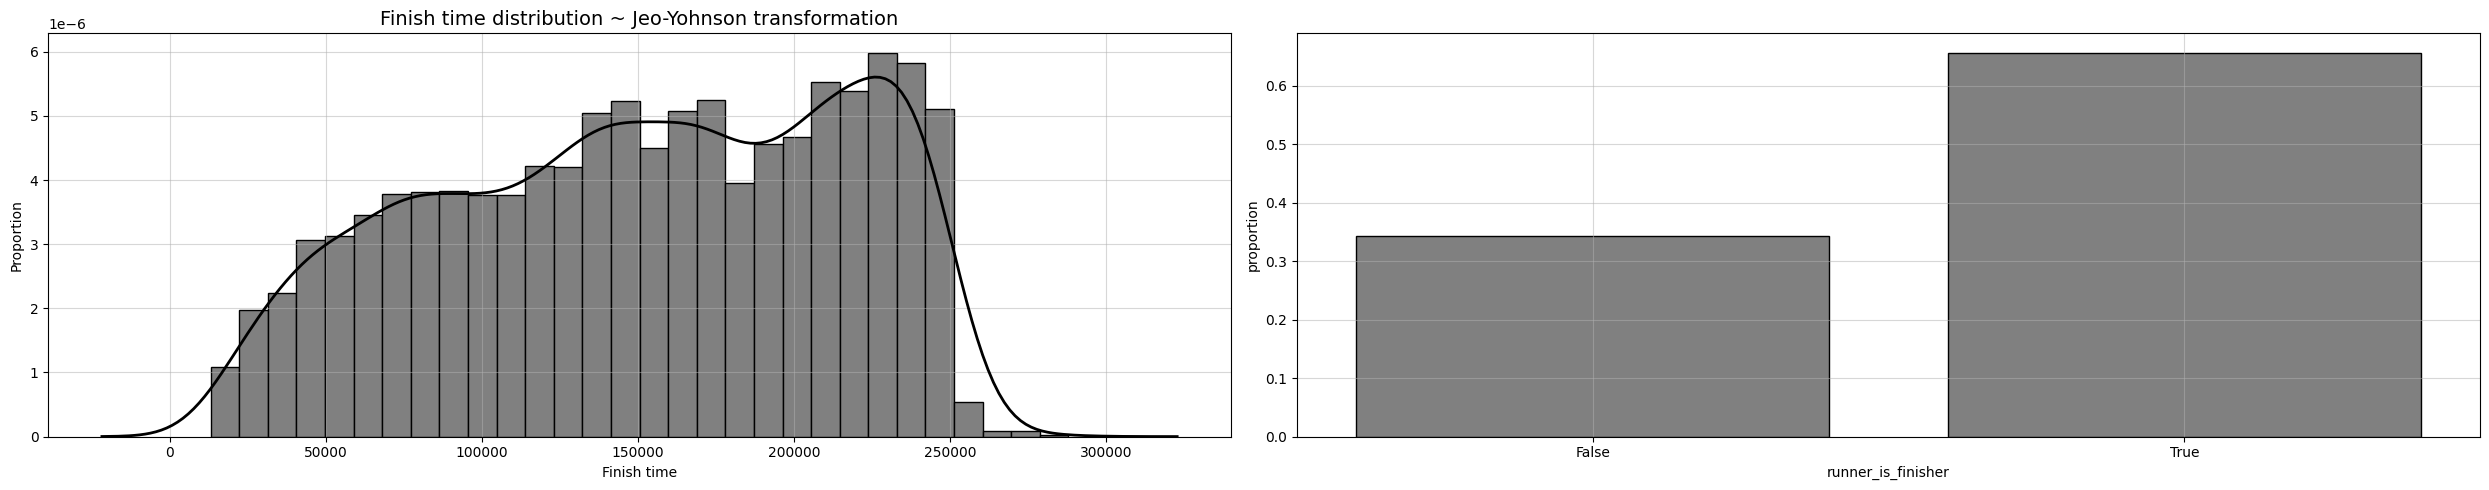

In [40]:
# Yeo-Johnson Finish time distribution & DNF proportion distribution
pt = PowerTransformer(method="yeo-johnson", standardize=False)
target = race_results_runner_statistics_finished_train["runner_race_time_hours"]
target_pt = pt.fit_transform(target.values.reshape(-1, 1)).flatten()

fix, ax = plt.subplots(1,2, figsize=(25,5))

ax[0].set_title("Succesfull Finish distribution", fontsize=14)
prop_df = race_results_runner_statistics_train["runner_is_finisher"].value_counts(normalize=True) .reset_index()
sns.barplot(x="runner_is_finisher", y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[1])
ax[0].set_xlabel("Finisher")
ax[0].set_ylabel("Proportion")


ax[0].set_title("Finish time distribution ~ Jeo-Yohnson transformation", fontsize=14)
ax[0].hist(target_pt, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(target_pt, ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Finish time")

for i in [0,1]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

In [ ]:
# Box-Cox transform finish times & Yeo-Johnson (PT) finish times

# Box-Cox
target_bc = race_results_runner_statistics_finished_train["runner_race_time_hours"]
lambda_bc = boxcox_normmax(target_bc)
race_results_runner_statistics_finished_train["runner_race_time_hours_bc"] = boxcox(target_bc, lmbda=lambda_bc)
race_results_runner_statistics_finished_train["runner_race_time_hours_inverse_bc"] = inv_boxcox(race_results_runner_statistics_finished_train["runner_race_time_hours_bc"], lambda_bc)

# Yeo-Johnson
pt = PowerTransformer(method="yeo-johnson", standardize=False)
target_pt =  race_results_runner_statistics_finished_train["runner_race_time_hours"]
race_results_runner_statistics_finished_train["runner_race_time_hours_pt"] = pt.fit_transform(target_pt.values.reshape(-1, 1)).flatten()
race_results_runner_statistics_finished_train["runner_race_time_hours_inverse_pt"] = pt.inverse_transform(race_results_runner_statistics_finished_train["runner_race_time_hours_pt"].values.reshape(-1, 1)).flatten()

Univariate analysis

In [66]:
# Univariate OLS numeric feature ~ Help function

def univariate_OLS_numeric(
        target: str, target_name: str, 
        feature: str, feature_name: str, 
        data: pd.DataFrame, 
        alpha: float=1.0,
        box_cox_transformation: bool=False, 
        print_metrics: bool=True,
        show_plot: bool=True
        ) -> pd.DataFrame:
    
    print("-----------------------------------------------------")
    print(f"{target_name} ~ {feature_name} ~> Univariate Linear Regression")
    print("-----------------------------------------------------\n")

    # Prepare data for modeling
    data = data.copy()

    if box_cox_transformation:
        target_name = target_name + " [Box-Cox Transformed]"
        target_bc = data[target]
        lambda_bc = boxcox_normmax(target_bc)
        data[target+"_bc"] = boxcox(target_bc, lmbda=lambda_bc)
        target = target+"_bc"

    data_clean = data[[target, feature]].dropna() 
    X = sm.add_constant(data_clean[[feature]])
    y = data_clean[target]

    model = sm.OLS(y, X)
    fit = model.fit()
    y_pred = fit.predict(X)

    if box_cox_transformation:
        prop_clipped = round((y_pred < 1e-6).mean(), 2)
        y_pred = np.where(y_pred < 1e-6, 1e-6, y_pred)
        
        y_pred = inv_boxcox(y_pred, lambda_bc)
        y = inv_boxcox(y, lambda_bc)

    # Metrics
    metrics = {
        "proportion of clipped Box-Cox predicted values": prop_clipped if box_cox_transformation else None,
        "coef": fit.params[feature],
        "scaled coef": fit.params[feature] / np.std(data_clean[feature]),
        "p-value": fit.pvalues[feature],
        "standard error": fit.bse[feature],
        "scaled standard error": fit.bse[feature] / np.std(data_clean[feature]),
        "confidence interval": round(fit.conf_int().loc[feature], 4).tolist(),
        "scaled confidence interval": round(fit.conf_int().loc[feature] / np.std(data_clean[feature]), 4).tolist(),
        "R2": fit.rsquared,
        "R2 adjusted": fit.rsquared_adj,
        "MAE": mean_absolute_error(y, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
        "Pearson correlation coefficient": pearsonr(y, y_pred)[0]
    }

    metrics_df = pd.DataFrame([metrics])
    metrics_df.insert(0, "feature", feature)

    if print_metrics:
        for key, value in metrics.items():
            if isinstance(value, list):
                print(f"{key} ~> {[f'{v:.4f}' for v in value]}")
            else:
                print(f"{key} ~> {value:.4f}" if isinstance(value, float) else f"{key} ~> {value}")

    # Plot
    if show_plot:
        fig, ax = plt.subplots(2, 2, figsize=(25, 10))

        # Feature distribution
        ax[0,0].set_title(f"{feature_name} Distribution", fontsize=14)
        ax[0,0].hist(data_clean[feature], bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
        sns.kdeplot(data_clean[feature], ax=ax[0,0], color="black", linewidth=2)
        ax[0,0].set_xlabel(feature_name)

        # Scatter plot with regression line
        ax[0,1].set_title(f"{target_name} ~ {feature_name} ~> Scatter plot & Regression line", fontsize=14)
        ax[0,1].scatter(data_clean[feature], data_clean[target], color="black", s=15, alpha=alpha)
        sns.regplot(x=data_clean[feature], y=data_clean[target], ax=ax[0,1], scatter=False, line_kws={"color":"red", "linewidth":2})
        ax[0,1].set_xlabel(feature_name)
        ax[0,1].set_ylabel(target_name)

        # Residuals scatter ~ Linearity assumption, Homoscedasticity, Outliers, Centering around zero
        ax[1,0].set_title("Predicted values vs. Residuals", fontsize=14)
        residuals = y - y_pred
        ax[1,0].scatter(y_pred, residuals, color="black", s=15, alpha=alpha)
        ax[1,0].axhline(0, color="red", linestyle="--")
        ax[1,0].set_xlabel(f"Predicted")
        ax[1,0].set_ylabel("Residuals")
        ax[1,0].set_title(f"Residuals vs Predicted for")

        # Residuals KDE ~ Normality assumption
        ax[1,1].set_title("Residuals distribution", fontsize=14)
        ax[1,1].hist(residuals, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
        sns.kdeplot(residuals, ax=ax[1,1], color="black", linewidth=2)
        ax[1,1].set_title(f"Residuals Distribution")
        ax[1,1].set_xlabel("Residuals")
        ax[1,1].set_ylabel("Density")

        for i in [0,1]:
            for j in [0,1]:
                ax[i,j].grid(alpha=.5)

        plt.tight_layout()
        plt.show()

    return metrics_df


-----------------------------------------------------
Race Time ~ Pre-race UTMB Index ~> Univariate Linear Regression
-----------------------------------------------------



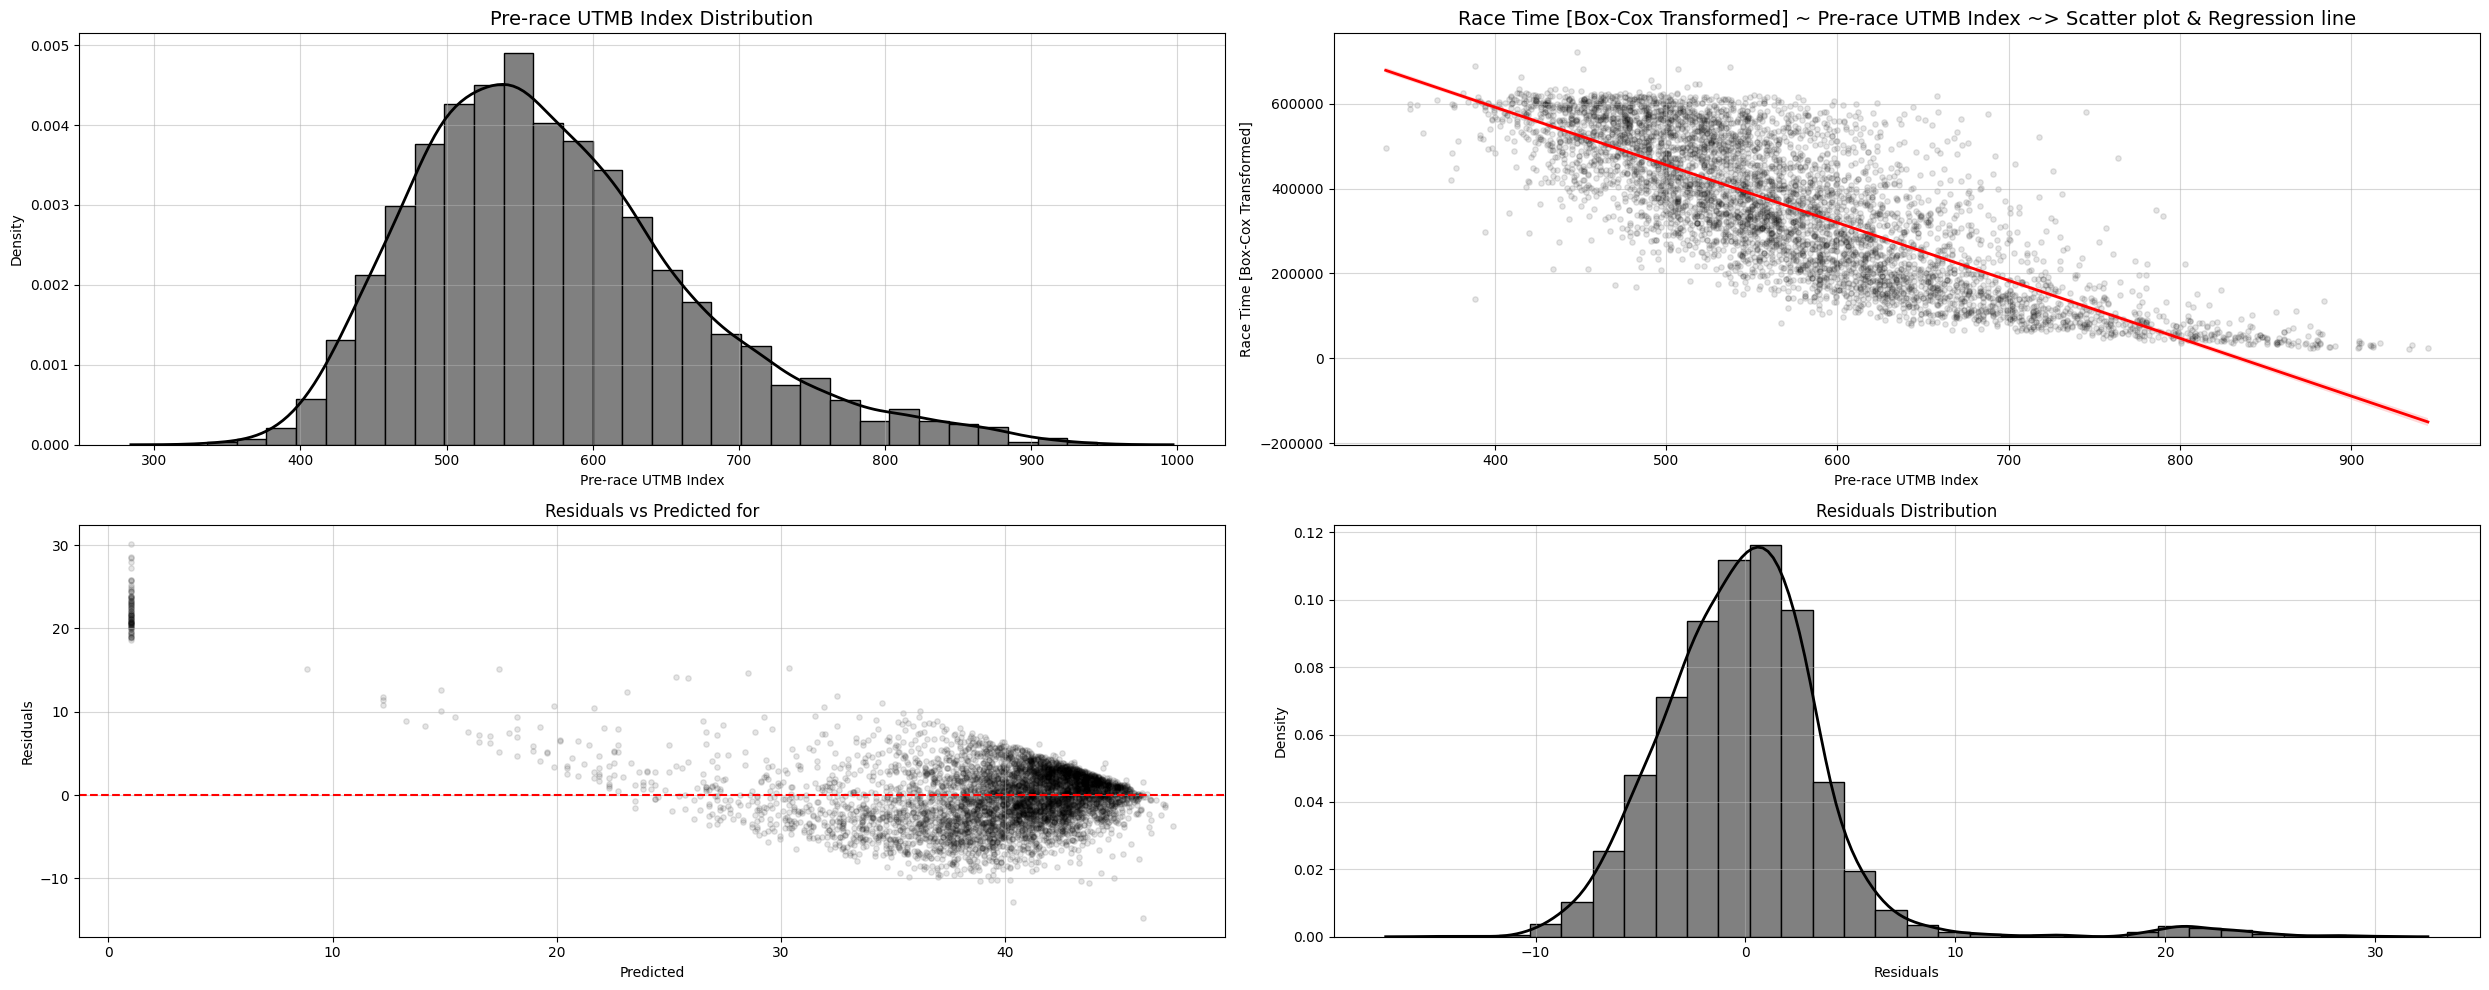

In [ ]:
# Race Time ~ Box Cox transform

box_cox_transformation = True

print_metrics = True
show_plot = True

_ = univariate_OLS_numeric(
    target = "runner_race_time_hours", target_name = "Race Time",
    feature = "runner_pre_race_index", feature_name = "Pre-race UTMB Index",
    data = race_results_runner_statistics_finished_train,
    alpha = 0.1,
    box_cox_transformation = True, 
    print_metrics = False,
    show_plot = True
    )

-----------------------------------------------------
Race Time ~ Pre-race UTMB Index ~> Univariate Linear Regression
-----------------------------------------------------



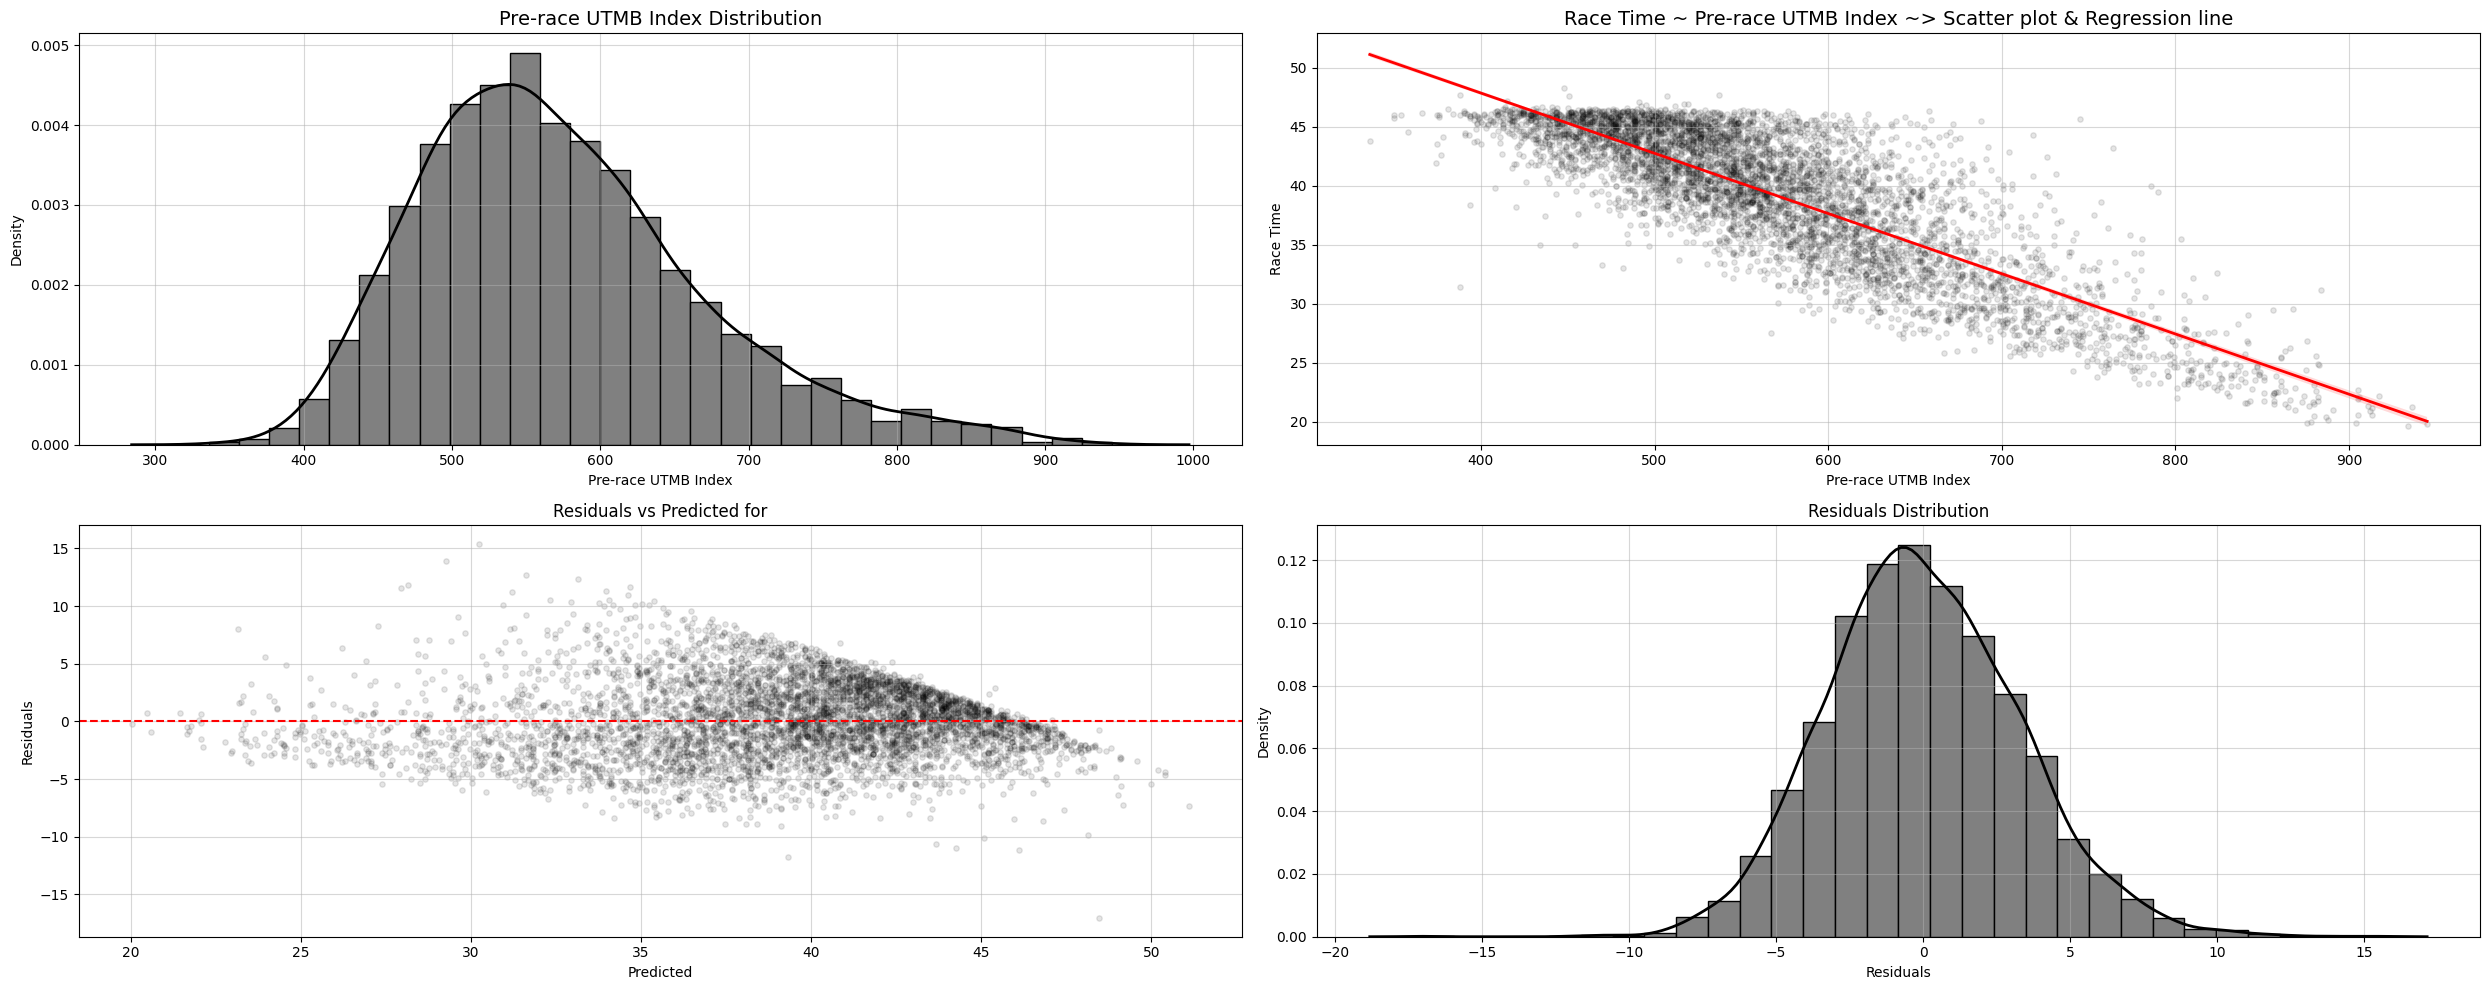

In [70]:
# Race Time ~ Original

box_cox_transformation = True

print_metrics = True
show_plot = True

_ = univariate_OLS_numeric(
    target = "runner_race_time_hours", target_name = "Race Time",
    feature = "runner_pre_race_index", feature_name = "Pre-race UTMB Index",
    data = race_results_runner_statistics_finished_train,
    alpha = 0.1,
    box_cox_transformation = False, 
    print_metrics = False,
    show_plot = True
    )